In [5]:
import pandas as pd

df = pd.read_csv("../dataset/advertising.csv")

df.drop("Unnamed: 0", axis=1, inplace=True)

print("Dataset Loaded Successfully ✅")
print(df.head())
print(df.shape)

Dataset Loaded Successfully ✅
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9
(200, 4)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [7]:
df = pd.read_csv("../dataset/advertising.csv")

df.drop("Unnamed: 0", axis=1, inplace=True)

print("Dataset Loaded Successfully ✅")
print(df.shape)

df.head()

Dataset Loaded Successfully ✅
(200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [10]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


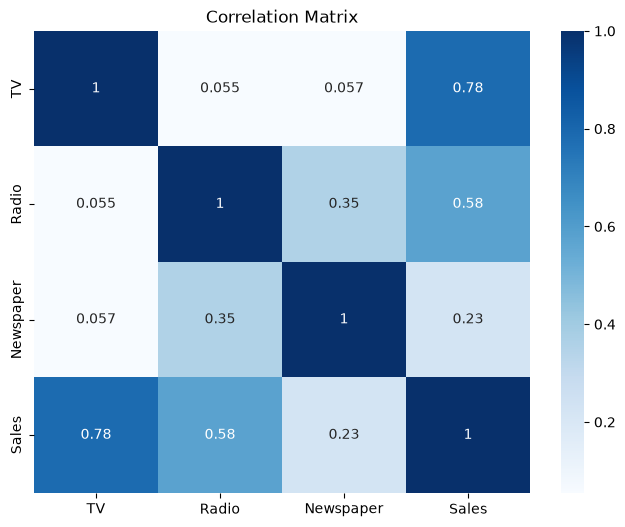

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

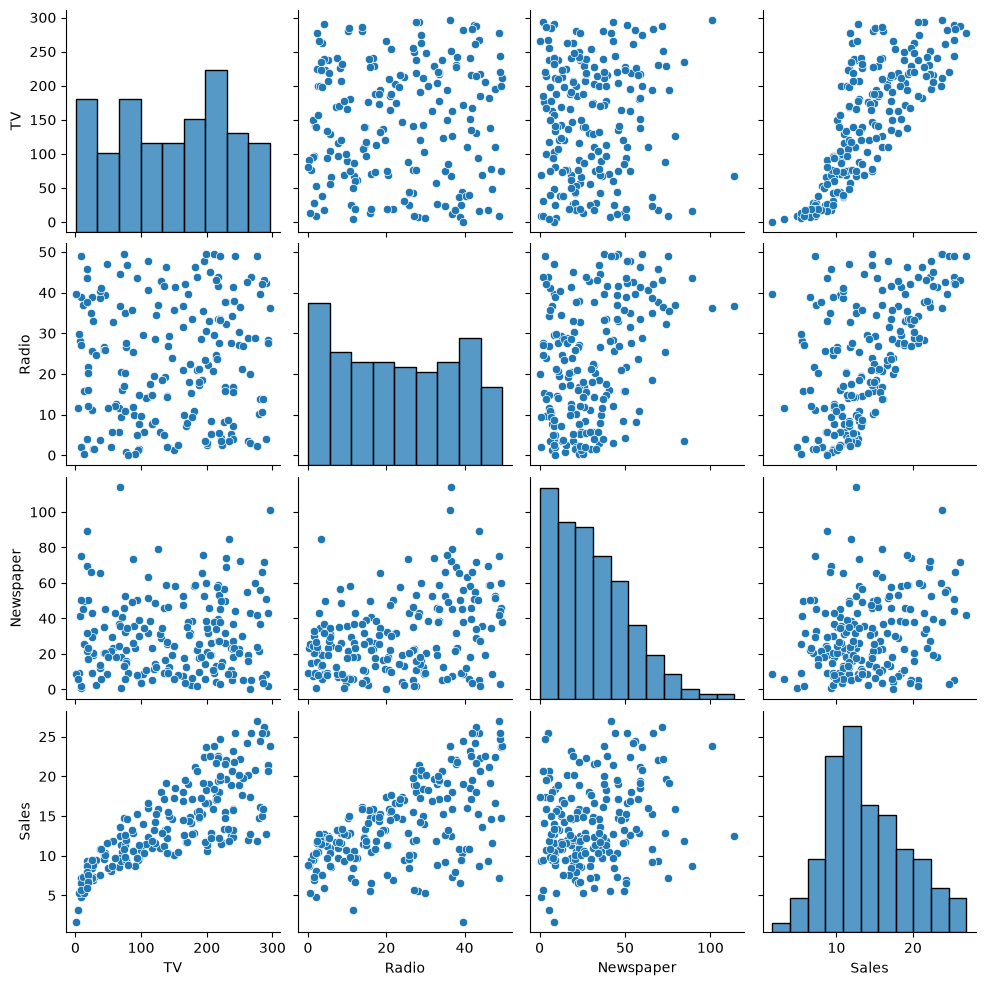

In [13]:
sns.pairplot(df)
plt.show()

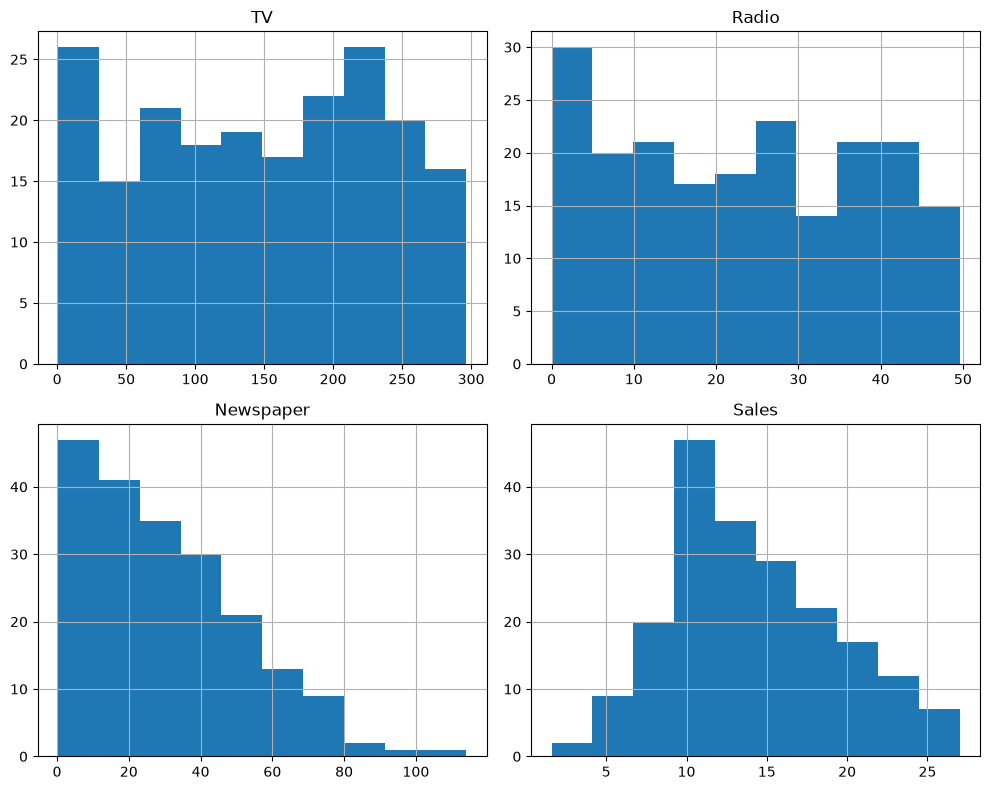

In [14]:
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

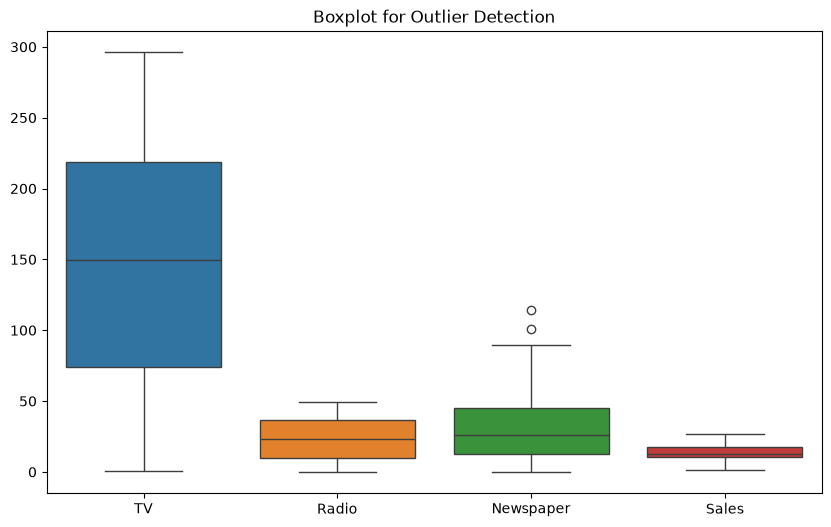

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [16]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (200, 3)
Target Shape : (200,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (160, 3)
Testing Data : (40, 3)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (160, 3)
Testing Data : (40, 3)


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [20]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_score = lr.score(X_test, y_test)

print("Linear Regression Accuracy :", lr_score)

Linear Regression Accuracy : 0.899438024100912


In [21]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_score = dt.score(X_test, y_test)

print("Decision Tree Accuracy :", dt_score)

Decision Tree Accuracy : 0.9310914968293178


In [22]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_score = rf.score(X_test, y_test)

print("Random Forest Accuracy :", rf_score)

Random Forest Accuracy : 0.9812782416450916


In [23]:
models = {
    "Linear Regression": lr_score,
    "Decision Tree": dt_score,
    "Random Forest": rf_score
}

for model, score in models.items():
    print(model, ":", round(score * 100, 2), "%")

Linear Regression : 89.94 %
Decision Tree : 93.11 %
Random Forest : 98.13 %


In [24]:
best_model = rf

print("Best Model Selected : Random Forest")

Best Model Selected : Random Forest


In [25]:
import joblib

joblib.dump(best_model, "../models/sales_prediction_model.pkl")

print("Model Saved Successfully ✅")

Model Saved Successfully ✅


In [27]:
sample = pd.DataFrame({
    "TV": [230.1],
    "Radio": [37.8],
    "Newspaper": [69.2]
})

prediction = best_model.predict(sample)

print("Predicted Sales:", prediction[0])

Predicted Sales: 21.991999999999965


<Axes: >

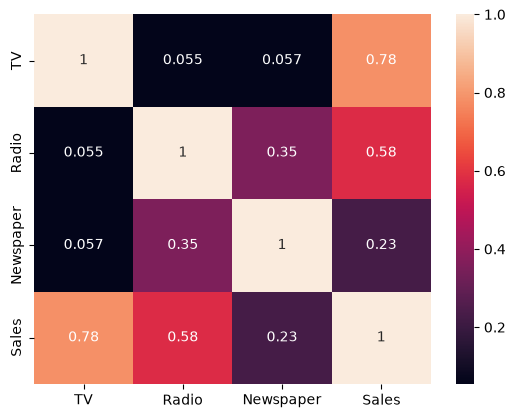

In [28]:
sns.heatmap(df.corr(), annot=True)

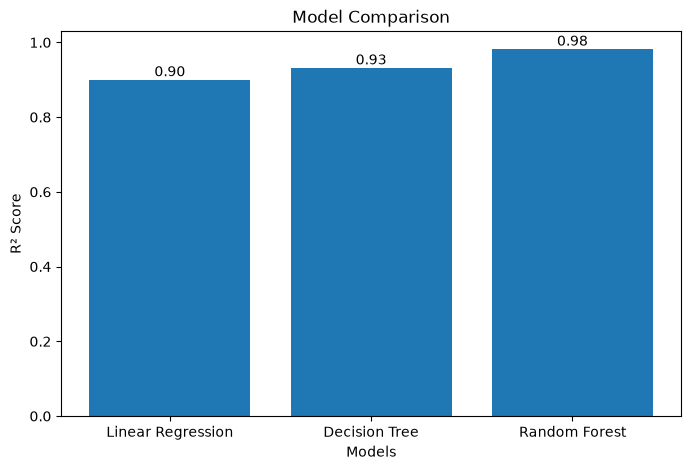

In [30]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Decision Tree", "Random Forest"]
scores = [lr_score, dt_score, rf_score]

plt.figure(figsize=(8,5))
plt.bar(models, scores)

plt.title("Model Comparison")
plt.ylabel("R² Score")
plt.xlabel("Models")

for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()